In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mattiuzc/stock-exchange-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'stock-exchange-data' dataset.
Path to dataset files: /kaggle/input/stock-exchange-data


In [13]:
df=pd.read_csv("/kaggle/input/stock-exchange-data/indexData.csv")

In [14]:
df.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,1965-12-31,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1966-01-03,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1966-01-04,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1966-01-05,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1966-01-06,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112457 entries, 0 to 112456
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Index      112457 non-null  object 
 1   Date       112457 non-null  object 
 2   Open       110253 non-null  float64
 3   High       110253 non-null  float64
 4   Low        110253 non-null  float64
 5   Close      110253 non-null  float64
 6   Adj Close  110253 non-null  float64
 7   Volume     110253 non-null  float64
dtypes: float64(6), object(2)
memory usage: 6.9+ MB


In [16]:
df.shape

(112457, 8)

In [17]:
df=df.drop(columns=['Adj Close','Volume'])
df=df.drop('Index',axis=1)

In [18]:
df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [19]:
df.isna().sum()

,0
Date,0
Open,2204
High,2204
Low,2204
Close,2204


In [20]:
df.duplicated().sum()

np.int64(789)

In [11]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [21]:
df.shape

(112457, 5)

In [22]:
df['Date']=pd.to_datetime(df['Date'])
df.set_index('Date',inplace=True)

In [23]:
df=df.sort_index()

In [24]:
df.head()

,Open,High,Low,Close
Date,,,,
1965-01-05,1257.719971,1257.719971,1257.719971,1257.719971
1965-01-06,1263.989990,1263.989990,1263.989990,1263.989990
1965-01-07,1274.270020,1274.270020,1274.270020,1274.270020
1965-01-08,1286.430054,1286.430054,1286.430054,1286.430054
1965-01-11,NaN,NaN,NaN,NaN


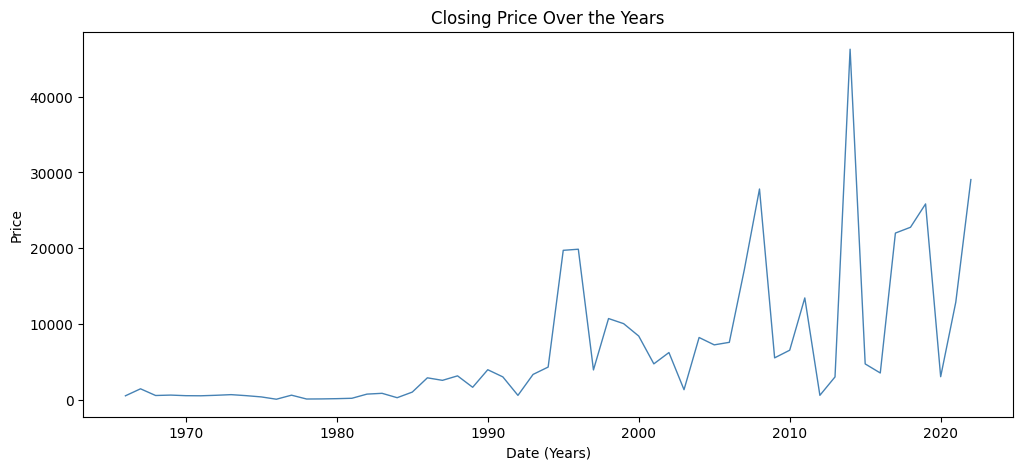

In [25]:
df_yearly = df['Close'].resample('YE').last()

plt.figure(figsize=(12, 5))
plt.plot(df_yearly.index, df_yearly, color='steelblue', linewidth=1)

plt.title('Closing Price Over the Years')
plt.xlabel('Date (Years)')
plt.ylabel('Price')

plt.show()

**Feature Engineering**

In [26]:
df['close-open'] = df['Close'] - df['Open']
df['high-low']= df['High'] - df['Low']

In [27]:
df['MA_5']=df['Close'].rolling(5).mean() #Moving Average of 5 days
df['MA_10']=df['Close'].rolling(10).mean() #Moving Average of 10 days
df['MA_20']=df['Close'].rolling(20).mean() #Moving Average of 20 days

In [28]:
df['Target']=df['Close'].shift(-1)

In [29]:
df['yesterday_close']=df['Close'].shift(1)

In [30]:
# Daily Return - todays close price - yesterday close price / yesterday close price
# df['daily_return']= (df['Close']-df['yesterday_close'])/df['yesterday_close']
df['daily_return'] = df['Close'].diff()

In [31]:
period = 14
df['gain'] = df['daily_return'].where(df['daily_return'] > 0, 0)
df['loss'] = (-df['daily_return']).where(df['daily_return'] < 0, 0)

df['avg_gain'] = df['gain'].rolling(period).mean()
df['avg_loss'] = df['loss'].rolling(period).mean()

df['rs']  = df['avg_gain'] / df['avg_loss']
df['rsi'] = 100 - (100 / (1 + df['rs']))

In [32]:
df.isna().sum()

,0
Open,2204
High,2204
Low,2204
Close,2204
close-open,2204
high-low,2204
MA_5,8285
MA_10,13726
MA_20,22528
Target,2205


In [33]:
df.dropna(inplace=True)

In [34]:
df.head()

,Open,High,Low,Close,close-open,high-low,MA_5,MA_10,MA_20,Target,yesterday_close,daily_return,gain,loss,avg_gain,avg_loss,rs,rsi
Date,,,,,,,,,,,,,,,,,,
1965-03-11,1164.630005,1164.630005,1164.630005,1164.630005,0.0,0.0,1183.404004,1195.995996,1215.723486,1175.859985,1173.339966,-8.709961,0.000000,8.709961,0.749285,5.943569,0.126067,11.195299
1965-03-12,1175.859985,1175.859985,1175.859985,1175.859985,0.0,0.0,1176.647998,1192.275000,1211.619488,1188.489990,1164.630005,11.229980,11.229980,0.000000,1.551426,5.048567,0.307300,23.506486
1965-03-15,1188.489990,1188.489990,1188.489990,1188.489990,0.0,0.0,1176.150000,1190.476001,1208.568988,1181.219971,1175.859985,12.630005,12.630005,0.000000,2.453570,4.960711,0.494600,33.092485
1965-03-16,1181.219971,1181.219971,1181.219971,1181.219971,0.0,0.0,1176.707983,1188.343994,1205.279486,1175.800049,1188.489990,-7.270019,0.000000,7.270019,2.453570,5.159284,0.475564,32.229301
1965-03-17,1175.800049,1175.800049,1175.800049,1175.800049,0.0,0.0,1177.200000,1185.142004,1202.215491,1182.689941,1181.219971,-5.419922,0.000000,5.419922,2.453570,5.375706,0.456418,31.338398


In [35]:
print(df['rsi'].describe())

count    89121.000000
mean        49.991071
std          4.901406
min         11.195299
25%         47.790387
50%         50.000887
75%         52.201054
max         93.530339
Name: rsi, dtype: float64


In [36]:
df[(df['rsi']>30) & (df['rsi']<70)].head()

,Open,High,Low,Close,close-open,high-low,MA_5,MA_10,MA_20,Target,yesterday_close,daily_return,gain,loss,avg_gain,avg_loss,rs,rsi
Date,,,,,,,,,,,,,,,,,,
1965-03-15,1188.489990,1188.489990,1188.489990,1188.489990,0.0,0.0,1176.150000,1190.476001,1208.568988,1181.219971,1175.859985,12.630005,12.630005,0.000000,2.453570,4.960711,0.494600,33.092485
1965-03-16,1181.219971,1181.219971,1181.219971,1181.219971,0.0,0.0,1176.707983,1188.343994,1205.279486,1175.800049,1188.489990,-7.270019,0.000000,7.270019,2.453570,5.159284,0.475564,32.229301
1965-03-17,1175.800049,1175.800049,1175.800049,1175.800049,0.0,0.0,1177.200000,1185.142004,1202.215491,1182.689941,1181.219971,-5.419922,0.000000,5.419922,2.453570,5.375706,0.456418,31.338398
1965-03-18,1182.689941,1182.689941,1182.689941,1182.689941,0.0,0.0,1180.811987,1182.107996,1199.279486,1175.880005,1175.800049,6.889892,6.889892,0.000000,2.945705,5.115705,0.575816,36.540814
1965-04-19,1136.130005,1136.130005,1136.130005,1136.130005,0.0,0.0,1147.541992,1157.876990,1153.270496,1131.170044,1148.209961,-12.079956,0.000000,12.079956,5.654288,5.916434,0.955692,48.867201


In [37]:
df[df['rsi'] > 70].head()

,Open,High,Low,Close,close-open,high-low,MA_5,MA_10,MA_20,Target,yesterday_close,daily_return,gain,loss,avg_gain,avg_loss,rs,rsi
Date,,,,,,,,,,,,,,,,,,
1965-08-17,1151.770020,1151.770020,1151.770020,1151.770020,0.0,0.0,1141.839990,1142.765991,1105.237482,1157.020020,1158.349976,-6.579956,0.000000,6.579956,9.812858,3.699995,2.652127,72.618699
1965-08-18,1157.020020,1157.020020,1157.020020,1157.020020,0.0,0.0,1148.826001,1144.936987,1110.803986,1168.619995,1151.770020,5.250000,5.250000,0.000000,8.814994,3.699995,2.382434,70.435492
1965-08-19,1168.619995,1168.619995,1168.619995,1168.619995,0.0,0.0,1156.484009,1146.427991,1117.431488,1165.810059,1157.020020,11.599975,11.599975,0.000000,8.801426,3.699995,2.378767,70.403407
1965-08-26,1198.380005,1198.380005,1198.380005,1198.380005,0.0,0.0,1183.472022,1169.978015,1150.006995,1214.949951,1198.910034,-0.530029,0.000000,0.530029,6.493565,2.742850,2.367452,70.303954
1965-08-27,1214.949951,1214.949951,1214.949951,1214.949951,0.0,0.0,1193.300000,1176.807007,1155.894495,1245.489990,1198.380005,16.569946,16.569946,0.000000,7.341422,2.742850,2.676567,72.800713


In [38]:
df[df['rsi'] < 30].head()


,Open,High,Low,Close,close-open,high-low,MA_5,MA_10,MA_20,Target,yesterday_close,daily_return,gain,loss,avg_gain,avg_loss,rs,rsi
Date,,,,,,,,,,,,,,,,,,
1965-03-11,1164.630005,1164.630005,1164.630005,1164.630005,0.0,0.0,1183.404004,1195.995996,1215.723486,1175.859985,1173.339966,-8.709961,0.000000,8.709961,0.749285,5.943569,0.126067,11.195299
1965-03-12,1175.859985,1175.859985,1175.859985,1175.859985,0.0,0.0,1176.647998,1192.275000,1211.619488,1188.489990,1164.630005,11.229980,11.229980,0.000000,1.551426,5.048567,0.307300,23.506486
1965-07-12,1020.489990,1020.489990,1020.489990,1020.489990,0.0,0.0,1035.277978,1048.376978,1064.087994,1026.770020,1032.949951,-12.459961,0.000000,12.459961,0.900713,6.867859,0.131149,11.594322
1965-07-13,1026.770020,1026.770020,1026.770020,1026.770020,0.0,0.0,1031.235986,1044.281982,1061.972998,1033.140015,1020.489990,6.280030,6.280030,0.000000,1.349287,5.949289,0.226798,18.486989
1965-07-14,1033.140015,1033.140015,1033.140015,1033.140015,0.0,0.0,1030.359985,1041.584985,1060.495996,1024.680054,1026.770020,6.369995,6.369995,0.000000,1.804286,5.912859,0.305146,23.380231


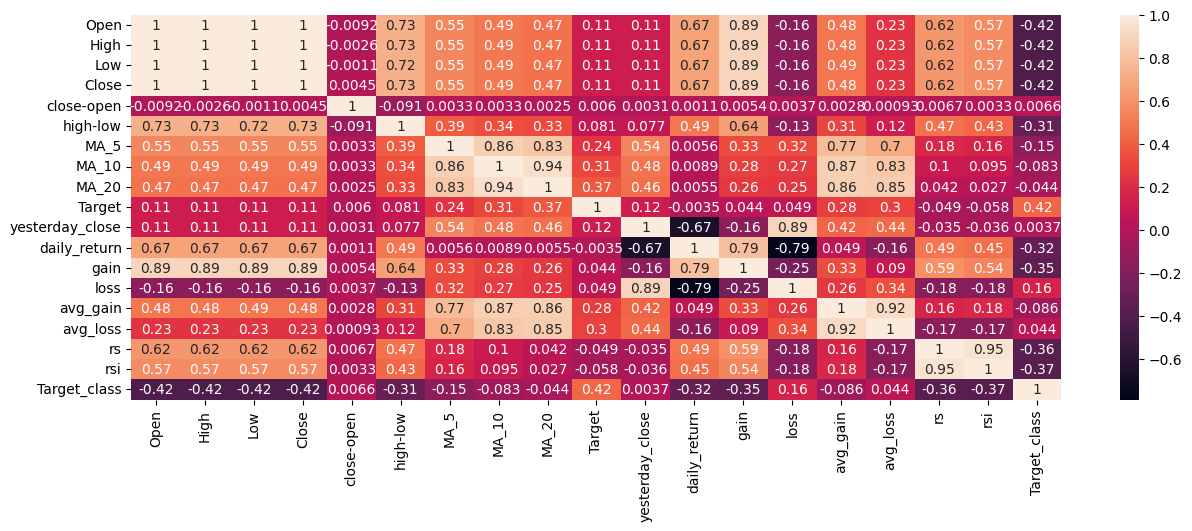

In [71]:
plt.figure(figsize=(15,5))
sns.heatmap(df.corr(),annot=True)
plt.show()

In [39]:
df['Target_class'] = (df['Close'].shift(-1) > df['Close']).astype(int)
print(df['Target_class'].value_counts())

Target_class
0    44688
1    44433
Name: count, dtype: int64


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [41]:
Predictors = ['close-open','high-low', 'High', 'Low', 'MA_5','MA_10','MA_20','daily_return','rsi']

In [42]:
X=df[Predictors].values
y=df['Target_class'].values

In [43]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,shuffle=False)

In [72]:
print(f"Shape of X_train: {X_train.shape[0]}")
print(f"Shape of X_test: {X_test.shape[0]}")

Shape of X_train: 71296
Shape of X_test: 17825


In [60]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

**Models (Training Phase)**

In [61]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix

In [62]:
Random_Forest = RandomForestClassifier(n_estimators=100, random_state=42,class_weight='balanced')
Random_Forest.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [63]:
y_pred_rf=Random_Forest.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=['Don\'t Buy (0)', 'BUY (1)']))

               precision    recall  f1-score   support

Don't Buy (0)       0.66      0.89      0.76      8958
      BUY (1)       0.83      0.53      0.65      8867

     accuracy                           0.71     17825
    macro avg       0.74      0.71      0.70     17825
 weighted avg       0.74      0.71      0.70     17825



In [64]:
Logisitic_Regression=LogisticRegression(max_iter=1000)
Logisitic_Regression.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [65]:
y_pred_lr=Logisitic_Regression.predict(X_test)
print(classification_report(y_test, y_pred_lr, target_names=['Don\'t Buy (0)', 'BUY (1)']))

               precision    recall  f1-score   support

Don't Buy (0)       0.73      0.78      0.75      8958
      BUY (1)       0.76      0.70      0.73      8867

     accuracy                           0.74     17825
    macro avg       0.74      0.74      0.74     17825
 weighted avg       0.74      0.74      0.74     17825



In [66]:
Knn=KNeighborsClassifier(n_neighbors=5)
Knn.fit(X_train, y_train)

KNeighborsClassifier()

In [54]:
y_pred_knn=Knn.predict(X_test)
print(classification_report(y_test, y_pred_knn, target_names=['Don\'t Buy (0)', 'BUY (1)']))

               precision    recall  f1-score   support

Don't Buy (0)       0.67      0.83      0.74      8958
      BUY (1)       0.78      0.59      0.67      8867

     accuracy                           0.71     17825
    macro avg       0.73      0.71      0.71     17825
 weighted avg       0.73      0.71      0.71     17825



In [55]:
svm=SVC()
svm.fit(X_train, y_train)

SVC()

In [56]:
y_pred_svm=svm.predict(X_test)
print(classification_report(y_test, y_pred_svm, target_names=['Don\'t Buy (0)', 'BUY (1)']))

               precision    recall  f1-score   support

Don't Buy (0)       0.64      0.93      0.76      8958
      BUY (1)       0.88      0.48      0.62      8867

     accuracy                           0.71     17825
    macro avg       0.76      0.71      0.69     17825
 weighted avg       0.76      0.71      0.69     17825



In [57]:
Naive_Bayes=GaussianNB()
Naive_Bayes.fit(X_train, y_train)

GaussianNB()

In [58]:
y_pred_nb=Naive_Bayes.predict(X_test)
print(classification_report(y_test, y_pred_nb, target_names=['Don\'t Buy (0)', 'BUY (1)']))

               precision    recall  f1-score   support

Don't Buy (0)       0.63      0.93      0.75      8958
      BUY (1)       0.87      0.44      0.58      8867

     accuracy                           0.69     17825
    macro avg       0.75      0.69      0.67     17825
 weighted avg       0.75      0.69      0.67     17825



**Model Loading**

In [67]:
import joblib

In [68]:
joblib.dump(Logisitic_Regression,'Logisitic_Regression_Stocks.pkl')

['Logisitic_Regression_Stocks.pkl']